# Object-Oriented Programming

In [1]:
import sys
from pathlib import Path

current = Path.cwd()
for parent in [current, *current.parents]:
    if (parent / '_config.yml').exists():
        project_root = parent
        break
else:
    project_root = Path.cwd().parent.parent

sys.path.insert(0, str(project_root))

from shared import thinkpython, diagram, jupyturtle, download

sys.modules['thinkpython'] = thinkpython
sys.modules['diagram'] = diagram
sys.modules['jupyturtle'] = jupyturtle
sys.modules['download'] = download


## Why Object-Oriented Programming?

Procedural programs organize code as a sequence of steps that transform data. As programs grow, this becomes hard to manage: data scattered across many variables, functions that need to know the internal layout of that data, and no natural grouping of related concepts.

**Object-Oriented Programming (OOP)** addresses this by bundling data and the functions that operate on it into a single unit called an **object**. Code that *uses* the object doesn't need to know how it works internally — only what it can do.

Python is an object-oriented language at its core. Every value you have used so far is already an object:

| Value | Type (Class) | Example method |
|---|---|---|
| `42` | `int` | `bit_length()` |
| `"hello"` | `str` | `upper()`, `split()` |
| `[1, 2, 3]` | `list` | `append()`, `sort()` |
| `{'a': 1}` | `dict` | `keys()`, `get()` |

When you call `[1, 2, 3].sort()`, you are calling the `sort` **method** of a `list` **object**. Methods are functions that belong to a class and operate on the data stored inside an instance.

## Classes and Instances

A **class** is a blueprint. An **instance** is one specific object created from that blueprint.

Think of a class as a cookie cutter and each instance as an individual cookie. The cutter defines the shape; every cookie produced from it is a separate object with its own toppings (attributes).

| Term | Meaning | Cookie analogy |
|---|---|---|
| Class | Blueprint / template | The cookie cutter |
| Instance | One object made from the class | A specific cookie |
| Attribute | Data stored on the instance | Icing color, sprinkles |
| Method | Function that belongs to the class | `decorate()`, `eat()` |

You create an instance by calling the class like a function:

```python
p = Point(3, 4)   # create one instance
q = Point(0, 0)   # create another — independent from p
```

`p` and `q` are two separate objects, each with their own data, created from the same `Point` class.

## A First Class

Here is the smallest useful class — a `Point` that represents a location in 2D space.

In [ ]:
class Point:
    """Represents a point (x, y) in 2D space."""

    def __init__(self, x, y):
        self.x = x          # store x as an attribute on this instance
        self.y = y          # store y as an attribute on this instance

    def distance_to(self, other):
        """Return Euclidean distance from this point to another."""
        return ((self.x - other.x) ** 2 + (self.y - other.y) ** 2) ** 0.5

    def __str__(self):
        return f"Point({self.x}, {self.y})"


p = Point(3, 4)
q = Point(0, 0)

print(p)                    # Point(3, 4)  — uses __str__
print(q)                    # Point(0, 0)
print(p.x, p.y)             # 3  4  — attribute access
print(p.distance_to(q))     # 5.0 — method call

In [ ]:
p = Point(1, 2)

print(type(p))               # <class '__main__.Point'>
print(type(p) is Point)      # True
print(isinstance(p, Point))  # True
print(isinstance(p, str))    # False

# All built-in types work the same way
print(type("hello"))         # <class 'str'>
print(isinstance(42, int))   # True
print(isinstance(42, float)) # False

## `isinstance()` and `type()`

Two built-in tools let you inspect objects:

- `type(obj)` — returns the class of the object
- `isinstance(obj, SomeClass)` — returns `True` if `obj` is an instance of that class (or a subclass)

Key parts of the code above:

| Part | What it does |
|---|---|
| `class Point:` | Declares the class |
| `def __init__(self, x, y):` | Constructor — runs automatically when you call `Point(3, 4)` |
| `self` | The instance being created or used; Python passes it automatically |
| `self.x = x` | Stores `x` as an *attribute* on this specific instance |
| `def __str__(self):` | Controls what `print()` shows; Python calls it automatically |
| `def distance_to(self, other):` | A regular method; `self` is this point, `other` is another `Point` |

## Classes and Functions

At this point you know how to use functions to organize code and how to use built-in types to organize data.
The next step is **object-oriented programming**, which uses programmer-defined types to organize both code and data.

Object-oriented programming is a big topic, so we will proceed gradually.
In this chapter, we'll start with code that is not idiomatic -- that is, it is not the kind of code experienced programmers write -- but it is a good place to start.
In the next two chapters, we will use additional features to write more idiomatic code.

### Programmer-Defined Types

We have used many of Python's built-in types -- now we will define a new type.
As a first example, we'll create a type called `Time` that represents a time of day.
A programmer-defined type is also called a **class**.
A class definition looks like this:

In [2]:
class Time:
    """Represents a time of day."""

The header indicates that the new class is called `Time`.
The body is a docstring that explains what the class is for.
Defining a class creates a **class object**.

The class object is like a factory for creating objects.
To create a `Time` object, you call `Time` as if it were a function.

In [3]:
lunch = Time()

The result is a new object whose type is `__main__.Time`, where `__main__` is the name of the  module where `Time` is defined.

In [4]:
type(lunch)

__main__.Time

When you print an object, Python tells you what type it is and where it is stored in memory (the prefix `0x` means that the following number is in hexadecimal).

In [5]:
print(lunch)

Creating a new object is called **instantiation**, and the object is an **instance** of the class.

### Attributes

An object can contain variables, which are called **attributes** and pronounced with the emphasis on the first syllable, like "AT-trib-ute", rather than the second syllable, like "a-TRIB-ute".
We can create attributes using dot notation.

In [6]:
lunch.hour = 11
lunch.minute = 59
lunch.second = 1

This example creates attributes called `hour`, `minute`, and `second`, which contain the hours, minutes, and seconds of the time `11:59:01`, which is lunch time as far as I am concerned.

The following diagram shows the state of `lunch` and its attributes after these assignments. 

In [7]:
from diagram import make_frame, make_binding

d1 = dict(hour=11, minute=59, second=1)
frame = make_frame(d1, name='Time', dy=-0.3, offsetx=0.48)
binding = make_binding('lunch', frame)

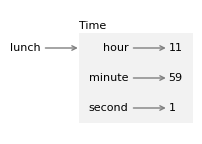

In [8]:
from diagram import diagram, adjust

width, height, x, y = [1.77, 1.24, 0.25, 0.86]
ax = diagram(width, height)
bbox = binding.draw(ax, x, y)
#adjust(x, y, bbox)

The variable `lunch` refers to a `Time` object, which contains three attributes. 
Each attribute refers to an integer.
A state diagram like this -- which shows an object and its attributes -- is called an **object diagram**.

You can read the value of an attribute using the dot operator.

In [9]:
lunch.hour

11

You can use an attribute as part of any expression.

In [10]:
total_minutes = lunch.hour * 60 + lunch.minute
total_minutes

719

And you can use the dot operator in an expression in an f-string.

In [11]:
f'{lunch.hour}:{lunch.minute}:{lunch.second}'

'11:59:1'

But notice that the previous example is not in the standard format.
To fix it, we have to print the `minute` and `second` attributes with a leading zero.
We can do that by extending the expressions in curly braces with a **format specifier**.
In the following example, the format specifiers indicate that `minute` and `second` should be displayed with at least two digits and a leading zero if needed.

In [12]:
f'{lunch.hour}:{lunch.minute:02d}:{lunch.second:02d}'

'11:59:01'

We'll use this f-string to write a function that displays the value of a `Time`object.
You can pass an object as an argument in the usual way.
For example, the following function takes a `Time` object as an argument. 

In [13]:
def print_time(time):
    s = f'{time.hour:02d}:{time.minute:02d}:{time.second:02d}'
    print(s)

When we call it, we can pass `lunch` as an argument.

In [14]:
print_time(lunch)

11:59:01


### Objects as Return Values

Functions can return objects. For example, `make_time` takes parameters called `hour`, `minute`, and `second`, stores them as attributes in a `Time` object, and returns the new object.

In [15]:
def make_time(hour, minute, second):
    time = Time()
    time.hour = hour
    time.minute = minute
    time.second = second
    return time

It might be surprising that the parameters have the same names as the attributes, but that's a common way to write a function like this.
Here's how we use `make_time` to create a `Time` object.

In [16]:
time = make_time(11, 59, 1)
print_time(time)

11:59:01


### Objects Are Mutable

Suppose you are going to a screening of a movie, like *Monty Python and the Holy Grail*, which starts at `9:20 PM` and runs for `92` minutes, which is one hour `32` minutes.
What time will the movie end?

First, we'll create a `Time` object that represents the start time.

In [17]:
start = make_time(9, 20, 0)
print_time(start)

09:20:00


To find the end time, we can modify the attributes of the `Time` object, adding the duration of the movie.

In [18]:
start.hour += 1
start.minute += 32
print_time(start)

10:52:00


The movie will be over at 10:52 PM.

Let's encapsulate this computation in a function and generalize it to take the duration of the movie in three parameters: `hours`, `minutes`, and `seconds`.

In [19]:
def increment_time(time, hours, minutes, seconds):
    time.hour += hours
    time.minute += minutes
    time.second += seconds

Here is an example that demonstrates the effect.

In [20]:
start = make_time(9, 20, 0)
increment_time(start, 1, 32, 0)
print_time(start)

10:52:00


The following stack diagram shows the state of the program just before `increment_time` modifies the object.

In [21]:
from diagram import Frame, Binding, Value, Stack

d1 = dict(hour=9, minute=20, second=0)
obj1 = make_frame(d1, name='Time', dy=-0.25, offsetx=0.78)

binding1 = make_binding('start', frame, draw_value=False, dx=0.7)
frame1 = Frame([binding1], name='__main__', loc='left', offsetx=-0.2)

binding2 = Binding(Value('time'), draw_value=False, dx=0.7, dy=0.35)
binding3 = make_binding('hours', 1)
binding4 = make_binding('minutes',32)
binding5 = make_binding('seconds', 0)
frame2 = Frame([binding2, binding3, binding4, binding5], name='increment_time', 
               loc='left', dy=-0.25, offsetx=0.08)

stack = Stack([frame1, frame2], dx=-0.3, dy=-0.5)

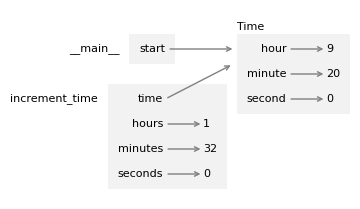

In [22]:
from diagram import Bbox

width, height, x, y = [3.4, 1.89, 1.75, 1.5]
ax = diagram(width, height)
bbox1 = stack.draw(ax, x, y)
bbox2 = obj1.draw(ax, x+0.23, y)
bbox = Bbox.union([bbox1, bbox2])
# adjust(x, y, bbox)

Inside the function, `time` is an alias for `start`, so when `time` is modified, `start` changes.

This function works, but after it runs, we're left with a variable named `start` that refers to an object that represents the *end* time, and we no longer have an object that represents the start time.
It would be better to leave `start` unchanged and make a new object to represent the end time.
We can do that by copying `start` and modifying the copy.